In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import cv2
import json
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import os

In [3]:
# 1. Copy the zip from Drive to Colab's local disk
!cp /content/drive/MyDrive/ISIC-Skin-cancer-dataset/jpeg-melanoma-256x256.zip /content/

# 2. Unzip it locally for the training session
!unzip -q /content/jpeg-melanoma-256x256.zip -d /content/melanoma_data/

In [4]:
!cp /content/drive/MyDrive/ISIC-training-csv/ISIC_2020_Train_Metadata.csv.zip /content/

!unzip -q /content/ISIC_2020_Train_Metadata.csv.zip -d /content/training_metadata-csv/


In [5]:
CSV_PATH = "/content/training_metadata-csv/ISIC_2020_Train_Metadata.csv"
IMG_DIR = "/content/melanoma_data/train"
MODEL_PATH = '/content/drive/MyDrive/ISIC-Skin-cancer-dataset/best_fusion_model.keras'

In [6]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [7]:
SAVE_DIR  = '/content/drive/MyDrive/ISIC-training-csv/weights'
VAL_CSV   = '/content/drive/MyDrive/ISIC-training-csv/val_processed.csv'
OUT_DIR   = '/content/drive/MyDrive/ISIC-training-csv/week3_outputs'
os.makedirs(OUT_DIR, exist_ok=True)

In [8]:
THRESHOLD = 0.22
IMG_SIZE = 256

In [9]:
META_COLS = ['sex_encoded', 'age_normalized', 'n_images_log', 'site_head/neck', 'site_lower extremity', 'site_oral/genital', 'site_palms/soles', 'site_torso', 'site_unknown', 'site_upper extremity']
N_META = len(META_COLS)

In [10]:
model = tf.keras.models.load_model(
    MODEL_PATH,
    compile = False # I only want to load the Prediction Brain. Leave the Grading Brain behind.
                    # I am not training this model anymore. I just want to make predictions
)

In [11]:
[i.shape for i in model.inputs]

[(None, 256, 256, 3), (None, 10)]

In [12]:
model.output

[<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_868>]

In [13]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ metadata_input      │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10)        │         40 │ metadata_input[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation_layer  │ (None, 256, 256,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 1280)      │  5,919,312 │ augmentation_lay… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ efficientnetv2-b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1312)      │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    336,128 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        257 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,258,521 (23.87 MB)

 Trainable params: 6,197,893 (23.64 MB)

 Non-trainable params: 60,628 (236.83 KB)

In [14]:
# Print last 10 layers name
for layer in model.layers[-10:]:
  print(layer.name)

augmentation_layer
dense
efficientnetv2-b0
dropout_1
dropout
dense_1
concatenate
dense_2
dropout_2
output


# Preprocessing functions

In [15]:
last_conv_layer_name = 'efficientnetv2-b0'

In [16]:
def remove_hair(img):
  """DullRazor hair removal using black-hat morphology."""

  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
  blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

  _, hair_mask = cv2.threshold(blackhat, 15, 255, cv2.THRESH_BINARY)

  cleaned = cv2.inpaint(img, hair_mask,
                        inpaintRadius=2,
                        flags=cv2.INPAINT_TELEA)

  return cleaned

In [17]:
def remove_artifacts(img):
  """Inpaints blue/purple surgical marker ink."""

  hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

  # Blue purple marker ink range in CSV
  lower_blue = np.array([90, 40, 40])
  upper_blue = np.array([150, 255, 255])
  artifact_mask = cv2.inRange(hsv, lower_blue, upper_blue)

  kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
  artifact_mask = cv2.dilate(artifact_mask, kernel, iterations=2)

  if artifact_mask.sum() > 100:
        return cv2.inpaint(img, artifact_mask, inpaintRadius=7, flags=cv2.INPAINT_TELEA)

  return img

In [18]:
def color_constancy(img, power=6):
  """Illumination normalization (Minkowski p-norm)."""

  img_float = img.astype(np.float32)

  norm_per_channel = np.power(
      np.mean(np.power(img_float, power), axis=(0, 1)),
      1.0/power
  )

  overall_norm = np.power(
     np.mean((np.power(norm_per_channel, 2))),
     1.0/2
  )

  img_constancy = img_float * (overall_norm/(norm_per_channel+ 1e-6))
  img_constancy = np.clip(img_constancy, 0, 255).astype(np.uint8)

  return img_constancy

In [19]:
def full_preprocess(img):
    """Executes the complete inference pipeline."""
    img = remove_hair(img)
    img = remove_artifacts(img)
    img = color_constancy(img)

    return img

In [20]:
def load_and_preprocess(img_name):
   """Load one image from disk, preprocess, resize, normalize."""

   path = os.path.join(IMG_DIR, img_name + '.jpg')
   img = cv2.imread(path)
   img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
   img = full_preprocess(img)
   img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

   return img

# Part-1 : GRAD-CAM HEATMAPS

## What is Grad-CAM?

**The problem:** Your model gives a prediction (e.g. 87% malignant). But *why*? Which part of the image caused that? Without explanation, no doctor trusts it.

**Grad-CAM solves this** by answering: "which pixels, if changed, would most change the prediction?"

**How it works conceptually:**
```
1. Run image through model → get prediction
2. Ask: how much does each feature map in the last conv layer
   affect the final prediction score?
   (this is the GRADIENT — rate of change)
3. Weight each feature map by its gradient
   (important maps get high weight, unimportant get low)
4. Average all weighted maps → one heatmap
5. Resize heatmap to image size → overlay on original image
```

**Result:** Red/hot areas = model looked here most. Blue/cold = model ignored this.

In [21]:
# Find the last Conv2D layer in the model
# This is where Grad-CAM reads the feature maps from
last_conv_layer_name = None

for layer in reversed(model.layers):
    if isinstance(layer, keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

if last_conv_layer_name is None:
    # EfficientNet wraps conv layers — try this fallback
    for layer in reversed(model.layers):
        if 'conv' in layer.name.lower() and 'bn' not in layer.name.lower():
            last_conv_layer_name = layer.name
            break

print(f'Last conv layer: {last_conv_layer_name}')
print()
print('This is the layer Grad-CAM will read gradients from.')
print('If this looks wrong, run Cell 5 and check the layer names printed there.')

Last conv layer: None

This is the layer Grad-CAM will read gradients from.
If this looks wrong, run Cell 5 and check the layer names printed there.


In [22]:
# Print layer names — we need this to find the right layer for Grad-CAM
print('Last 10 layer names (to identify the conv layer for Grad-CAM):')
for layer in model.layers[-10:]:
    print(f'  {layer.name:50s} {type(layer).__name__}')

Last 10 layer names (to identify the conv layer for Grad-CAM):
  augmentation_layer                                 Sequential
  dense                                              Dense
  efficientnetv2-b0                                  Functional
  dropout_1                                          Dropout
  dropout                                            Dropout
  dense_1                                            Dense
  concatenate                                        Concatenate
  dense_2                                            Dense
  dropout_2                                          Dropout
  output                                             Dense


In [23]:
# Find the correct last conv layer inside EfficientNetV2-B0
backbone = model.get_layer('efficientnetv2-b0')

last_conv_layer = None
for layer in reversed(backbone.layers):
    if isinstance(layer, keras.layers.Conv2D):
        last_conv_layer = layer.name
        print(f'Found: {layer.name}  |  output shape: {layer.output.shape}')
        break

print(f'\nUse this: last_conv_layer_name = "{last_conv_layer}"')

Found: top_conv  |  output shape: (None, None, None, 1280)

Use this: last_conv_layer_name = "top_conv"


In [24]:
last_conv_layer_name = 'top_conv'

In [25]:
for layer in model.layers:
    try:
        print(f"{layer.name:45s} {str(layer.output_shape)}")
    except:
        print(f"{layer.name:45s} shape unavailable")

metadata_input                                shape unavailable
image_input                                   shape unavailable
batch_normalization                           shape unavailable
augmentation_layer                            (None, 256, 256, 3)
dense                                         shape unavailable
efficientnetv2-b0                             (None, 1280)
dropout_1                                     shape unavailable
dropout                                       shape unavailable
dense_1                                       shape unavailable
concatenate                                   shape unavailable
dense_2                                       shape unavailable
dropout_2                                     shape unavailable
output                                        shape unavailable


In [26]:
# Pick one patient from validation set
df_val       = pd.read_csv(VAL_CSV).fillna(0)
patient_data = df_val.sample(14).iloc[0]

# Load and preprocess image
original_img = load_and_preprocess(patient_data['image_name'])

# Prepare model inputs
img_tensor  = np.expand_dims(original_img, axis=0).astype(np.float32) / 255.0
meta_tensor = np.expand_dims(
    patient_data[META_COLS].values.astype(np.float32), axis=0
)

# Labels for the plot
actual_text    = 'MALIGNANT' if patient_data['target'] == 1 else 'BENIGN'
prob           = float(model.predict([img_tensor, meta_tensor], verbose=0)[0][0])
predicted_text = 'Malignant' if prob >= THRESHOLD else 'Benign'

print(f'Patient: {patient_data["image_name"]}')
print(f'Actual:    {actual_text}')
print(f'Predicted: {predicted_text} ({prob*100:.1f}%)')

Patient: ISIC_1240189
Actual:    BENIGN
Predicted: Malignant (32.4%)


In [27]:
def make_scorecam_heatmap(img_array, meta_array, model, grid_size=14):
    """
    Optimized ScoreCAM — batches all masks in one predict call.
    grid_size=14 → 196 masks, good balance of speed and resolution.
    grid_size=20 → 400 masks, smoother but slower.
    """
    h, w        = 256, 256
    n_masks     = grid_size * grid_size
    img_single  = img_array[0]   # remove batch dim → (256, 256, 3)

    # Build all masked images at once
    all_masked_imgs  = np.zeros((n_masks, h, w, 3), dtype=np.float32)
    all_masked_metas = np.repeat(meta_array, n_masks, axis=0)

    idx = 0
    for row in range(grid_size):
        for col in range(grid_size):
            mask = np.zeros((h, w, 3), dtype=np.float32)
            r_start = int(row * h / grid_size)
            r_end   = int((row + 1) * h / grid_size)
            c_start = int(col * w / grid_size)
            c_end   = int((col + 1) * w / grid_size)
            mask[r_start:r_end, c_start:c_end, :] = 1.0
            all_masked_imgs[idx] = img_single * mask
            idx += 1

    # One single predict call for all masks
    print(f'Running {n_masks} masks in one batch...')
    scores = model.predict(
        [all_masked_imgs, all_masked_metas],
        batch_size=32,
        verbose=0
    ).squeeze()   # shape (n_masks,)

    # Reshape scores into 2D heatmap
    heatmap = scores.reshape(grid_size, grid_size).astype(np.float32)

    # Normalize
    heatmap -= heatmap.min()
    if heatmap.max() > 0:
        heatmap /= heatmap.max()

    heatmap = 1-heatmap

    print(f'Done. Heatmap range: {heatmap.min():.3f} – {heatmap.max():.3f}')
    return heatmap

In [28]:
def overlay_heatmap_on_image(original_img, heatmap, alpha=0.35):

  # Resize heatmap from (8,8) to full image size (256,256)
  heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))

  # Convert to colormap
  # COLORMAP_JET: blue=cold(low attention) → green → red=hot(high attention)
  # COLORMAP_INFERNO: black → purple → orange → yellow (more clinical look)
  heatmap_uint8 = np.uint8(255*heatmap_resized)
  heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
  heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

  # Blend original image and heatmap
  superimposed = cv2.addWeighted(
      original_img.astype(np.float32), 1-alpha,
      heatmap_color.astype(np.float32), alpha, 0
  )

  heatmap = np.uint8(superimposed)
  return heatmap

In [29]:
heatmap     = make_scorecam_heatmap(img_tensor, meta_tensor, model, grid_size=14)
overlay_img = overlay_heatmap_on_image(original_img, heatmap)

Running 196 masks in one batch...
Done. Heatmap range: 0.000 – 1.000


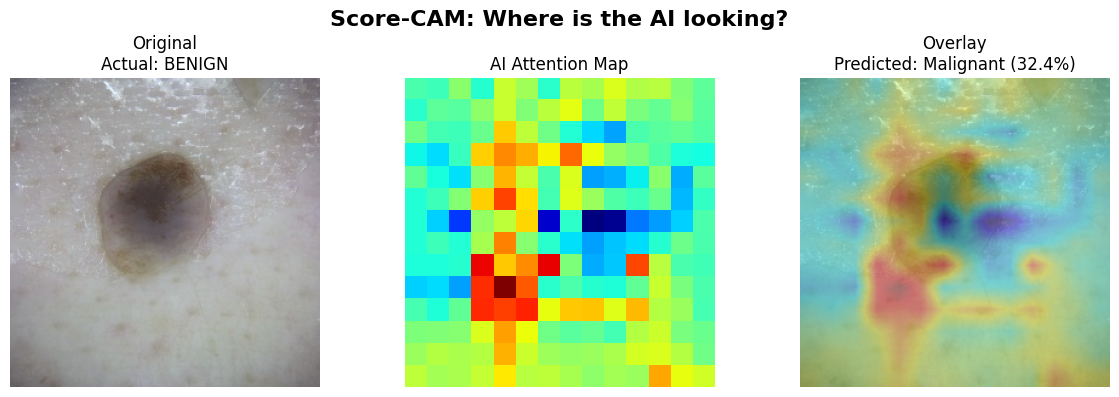

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Score-CAM: Where is the AI looking?', fontsize=16, fontweight='bold')

axes[0].imshow(original_img)
axes[0].set_title(f'Original\nActual: {actual_text}')
axes[0].axis('off')

axes[1].imshow(heatmap, cmap='jet')
axes[1].set_title('AI Attention Map')
axes[1].axis('off')

axes[2].imshow(overlay_img)
axes[2].set_title(f'Overlay\nPredicted: {predicted_text} ({prob*100:.1f}%)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

---
# PART 2 — MC DROPOUT UNCERTAINTY

## What is MC Dropout?

**The problem:** Your model outputs a single number — e.g. 0.73 (73% malignant). But is it *confident*? Or is it guessing? A model can output 0.73 whether it's very sure or completely uncertain. Standard inference doesn't tell you which.

**MC Dropout solves this** by running inference multiple times with dropout kept ON during inference (normally dropout is turned off at test time). Each run produces a slightly different prediction because different neurons are randomly dropped. The variance across runs measures uncertainty.

```
Run 1:  dropout mask A → prediction 0.81
Run 2:  dropout mask B → prediction 0.79
Run 3:  dropout mask C → prediction 0.77
...20 runs...
Mean:   0.79  ← final prediction
Std:    0.02  ← LOW uncertainty → model is confident

vs.

Run 1:  dropout mask A → prediction 0.61
Run 2:  dropout mask B → prediction 0.29
Run 3:  dropout mask C → prediction 0.48
...20 runs...
Mean:   0.43  ← final prediction
Std:    0.14  ← HIGH uncertainty → flag for dermatologist review
```

In [31]:
def predict_with_mc_dropout(model, img_input, meta_input, n_passes=20):
  """
    Run inference n_passes times with dropout ACTIVE.

    Args:
        model:      trained model
        img_input:  normalized image, shape (1, 256, 256, 3)
        meta_input: metadata, shape (1, N_META)
        n_passes:   how many times to run inference
                    20 is enough — more gives diminishing returns

    Returns:
        mean_prob:  average prediction across all passes
        std_prob:   standard deviation — the uncertainty score
        all_probs:  all n_passes predictions (for plotting)
  """

  predictions = []

  for i in range(n_passes):
    # training=True - keeps dropout active during inference
    pred = model(
        [img_input, meta_input],
        training = True           # This is what makes it MC dropout
    )

    predictions.append(float(pred[0][0]))

  predictions = np.array(predictions)
  mean_prob = np.mean(predictions)
  std_prob = np.std(predictions)

  return mean_prob, std_prob, predictions

In [32]:
def get_uncertainty_label(uncertainty_score):
  """
  Convert numerical uncertainty into a human-readable label.
  Standard deviation (uncertainty) is usually between 0.0 and 0.3
  """

  if uncertainty_score < 0.05:
    return 'High Confidence', 'Green'

  if uncertainty_score < 0.10:
    return 'Moderate Confidence', 'Orange'

  else:
    return 'Low Confidence -  Dermatologist Review Recommended', 'Red'

In [33]:
test_patient = df_val.sample(1).iloc[0]
image_id = test_patient['image_name']

test_metadata = test_patient[META_COLS]
test_patient[META_COLS].fillna(0).values.astype(np.float32)


array([0.       , 0.7222222, 1.609438 , 0.       , 0.       , 0.       ,
       0.       , 1.       , 0.       , 0.       ], dtype=float32)

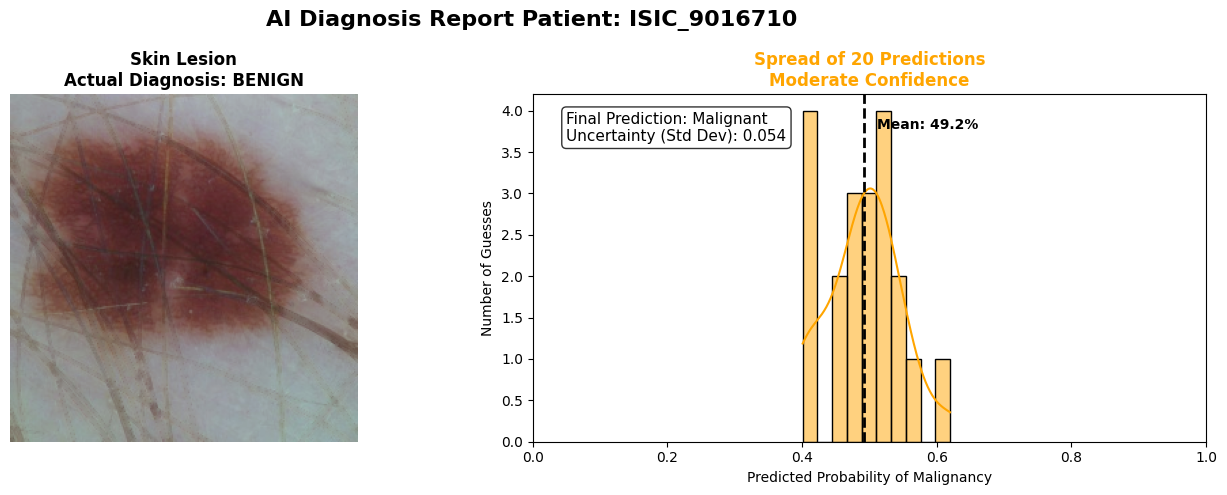

In [34]:
import seaborn as sns

test_patient = df_val.sample(1).iloc[0]
image_id = test_patient['image_name']

test_metadata = test_patient[META_COLS].fillna(0).values.astype(np.float32)

original_img = load_and_preprocess(image_id)

# Add the batch dimension for the model
img_tesnor = np.expand_dims(original_img, axis=0).astype(np.float32)

img_tensor = img_tensor / 255.0

meta_tensor = np.expand_dims(test_metadata, axis=0)


# Running the MC dropout
mean_prob, std_prob, all_probs = predict_with_mc_dropout(model, img_tesnor, meta_tensor, n_passes=20)
confidence_label, label_color = get_uncertainty_label(std_prob)

actual_text = "MALIGNANT" if test_patient['target'] == 1 else "BENIGN"
predicted_texxt = "Malignant" if mean_prob >= THRESHOLD else "Benign"


#  Visualize the result
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
fig.suptitle(f"AI Diagnosis Report Patient: {image_id}", fontsize=16, fontweight='bold')

# Left Plot: The Original Image
axes[0].imshow(original_img)
axes[0].set_title(f"Skin Lesion\nActual Diagnosis: {actual_text}", fontweight='bold')
axes[0].axis('off')

# Right Plot: The MC Dropout Histogram
sns.histplot(all_probs, bins=10, kde=True, ax=axes[1], color=label_color, edgecolor='black')

axes[1].axvline(mean_prob, color='black', linestyle='dashed', linewidth=2)
axes[1].text(mean_prob + 0.02, axes[1].get_ylim()[1]*0.9, f'Mean: {mean_prob*100:.1f}%', fontweight='bold')

axes[1].set_title(f"Spread of 20 Predictions\n{confidence_label}", color=label_color, fontweight='bold')
axes[1].set_xlabel("Predicted Probability of Malignancy")
axes[1].set_ylabel("Number of Guesses")
axes[1].set_xlim(0, 1.0)

# Add a text box with the hard numbers
stats_text = f"Final Prediction: {predicted_text}\nUncertainty (Std Dev): {std_prob:.3f}"
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
axes[1].text(0.05, 0.95, stats_text, transform=axes[1].transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# Final Inference Pipeline

### TTA and MC Dropout together

In [35]:
def predict_tta_mc(model, img_tensor, meta_tensor, n_passes=20):
  """
  Combines TTA (4 angles) with MC Dropout (20 passes)
  Total predictions: 80 per patient.
  """

  # TTA verification
  img_array = img_tensor[0]
  tta_batch = tf.stack([
      img_array,
      tf.image.flip_left_right(img_array), # Horizontal Flip
      tf.image.flip_up_down(img_array), # Horizontal flip
      tf.image.rot90(img_array, k=1)  # 90 degree rotation
  ])

  # Duplicate metadata 4 times to match 4 images
  meta_batch = tf.repeat(meta_tensor, repeats=4, axis=0)

  # Run MC dropoout loop
  all_80_scores = []

  for i in range(n_passes):
    # Pass all 4 images at once with Dropout forced ON (training=True)
    predictions = model([tta_batch, meta_batch], training=True)

    scores = predictions[:, 0].numpy().tolist()
    all_80_scores.extend(scores)


  # Calculate the final
  all_80_scores = np.array(all_80_scores)

  final_averaged_score = np.mean(all_80_scores)
  total_uncertainty = np.std(all_80_scores)

  return final_averaged_score, total_uncertainty

In [36]:
import base64
import io
from PIL import Image


def numpy_to_base64(img_array):
  """
  Convert a numpy image array to a base64 string.
  This is how we send images through the FastAPI response JSON.
  The React frontend decodes this string and displays the image.
  """

  # Convert numpy array to PIL Image
  pil_img = Image.fromarray(img_array)

  # Save the image to a BytesIO object
  buffer = io.BytesIO()
  pil_img.save(buffer, format="PNG")

  # Encode to base64 string
  b64_string = base64.b64encode(buffer.getvalue()).decode('utf-8')

  return f'data:image/png;base64,{b64_string}'

In [37]:
def run_full_inference(img_path, patient_metadata, model,
                       meta_cols, threshold, grid_size=14,
                       img_size=256, n_mc_passes=20):
  """
  Full inference pipeline - called by FastAPI backend

  Returns:
     dict with all results — ready to return from FastAPI endpoint
  """

  ## ----------- 1. Load and Preprocess image--------
  raw_img = cv2.imread(img_path)

  raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
  proc_img = full_preprocess(raw_img)
  resized = cv2.resize(proc_img, (img_size, img_size))

  img_norm = resized.astype(np.float32) / 255.0
  img_input = np.expand_dims(img_norm, axis=0)

  ## --------- 2. Build metadata features---------
  meta_dict = {
      'sex_encoded' : 1.0 if patient_metadata.get('sex') == 'male' else 0.0,
      'age_normalized' : patient_metadata.get('age', 45)/90,
      'n_images_log' : np.log1p(patient_metadata.get('n_images_per_patient', 1))
  }

  site_options = ['torso', 'lower extremity', 'upper extremity',
                    'head/neck', 'palms/soles', 'oral/genital']

  patient_site = patient_metadata.get('anatom_site', '')

  # Clean variable name
  for site in site_options:
    key = 'site_' + site.replace('', '_').replace('/', '_')
    meta_dict[key] = 1.0 if site == patient_site else 0.0

  meta_vector = np.array([meta_dict.get(col, 0.0) for col in meta_cols], dtype=np.float32)
  meta_input = np.expand_dims(meta_vector, axis=0)

  ## ------- 3. MC-TTA predictions--------
  mean_prob, std_prob = predict_tta_mc(
      model,img_input, meta_input, n_passes=n_mc_passes
  )

  ## --------- 4. Decision-----------
  is_malignant = mean_prob >= threshold
  uncertainty_label, _ = get_uncertainty_label(std_prob)

  ##---------- 5. Score-CAM Heatmap----------
  heatmap = make_scorecam_heatmap(img_input, meta_input, model, grid_size=grid_size)

  # Overlay  heatmap
  overlay = overlay_heatmap_on_image(resized, heatmap)

  # convert to base64
  original_b64 = numpy_to_base64(resized)
  overlay_b64 = numpy_to_base64(overlay)

  ## ------ 6. Return structured result --------
  return {
      'prediction': 'Malignant' if is_malignant else 'Benign',
      'probabiliy': round(float(mean_prob)*100, 1),
      'is_malignant': bool(is_malignant),
      'uncertainty_std': round(float(std_prob), 4),
      'uncertainty_label': uncertainty_label,
      'requires_reiew': std_prob >= 0.10,
      'urgent': is_malignant and std_prob<0.10,
      'threshold_used': threshold,
      'disclaimer': 'For clinical decision support only. Not a substitute for dermatologist review.',
      'original_image_b64': original_b64,
      'heatmap_overlay_b64': overlay_b64
  }


Simulating API Request for Patient: ISIC_3394520...
Running 196 masks in one batch...
Done. Heatmap range: 0.000 – 1.000

🩺 CLINICAL JSON PAYLOAD (What React receives)
  prediction           : Malignant
  probabiliy           : 35.4
  is_malignant         : True
  uncertainty_std      : 0.0534
  uncertainty_label    : Moderate Confidence
  requires_reiew       : False
  urgent               : True
  threshold_used       : 0.22
  disclaimer           : For clinical decision support only. Not a substitute for dermatologist review.




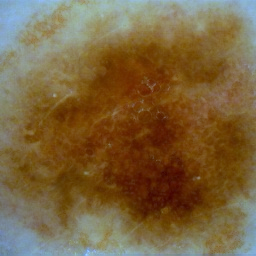
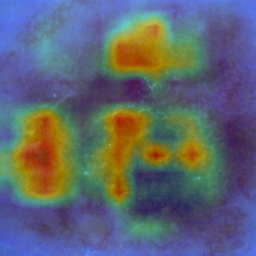

In [39]:
import os
from IPython.display import HTML, display

# --- 1. SIMULATE THE FRONTEND REQUEST ---
# Let's purposefully grab a Malignant patient so we can see the heatmap react!
test_patient = df_val[df_val['target'] == 1].iloc[14]
test_path = os.path.join(IMG_DIR, test_patient['image_name'] + '.jpg')

# This is exactly what the React frontend will send your FastAPI backend
mock_react_payload = {
    'sex': 'male',
    'age': 65,
    'anatom_site': 'torso',
    'n_images_per_patient': 3
}

print(f"Simulating API Request for Patient: {test_patient['image_name']}...")

# --- 2. RUN THE PIPELINE ---
result = run_full_inference(
    img_path=test_path,
    patient_metadata=mock_react_payload,
    model=model,
    meta_cols=META_COLS,
    threshold=THRESHOLD,
    grid_size=14,
    img_size=256,
    n_mc_passes=20
)

# --- 3. VERIFY THE TEXT PAYLOAD ---
print("\n" + "="*55)
print("🩺 CLINICAL JSON PAYLOAD (What React receives)")
print("="*55)
for key, value in result.items():
    if 'b64' not in key:  # Keep the console clean by hiding the giant image strings!
        print(f"  {key:20s} : {value}")
print("="*55 + "\n")

# --- 4. VERIFY THE VISUAL PAYLOAD (BASE64 DECODING) ---
# We use HTML to force the notebook to render the raw Base64 text back into pictures
html_str = f"""
<div style="display: flex; gap: 20px; font-family: sans-serif;">
    <div style="text-align: center;">
        <h4 style="margin-bottom: 5px;">What the Doctor Uploads</h4>
        <img src="{result['original_image_b64']}" style="border: 2px solid #333; border-radius: 8px; width: 256px; box-shadow: 2px 2px 10px rgba(0,0,0,0.5);" />
    </div>
    <div style="text-align: center;">
        <h4 style="margin-bottom: 5px;">What the AI Returns</h4>
        <img src="{result['heatmap_overlay_b64']}" style="border: 2px solid #D85A30; border-radius: 8px; width: 256px; box-shadow: 2px 2px 10px rgba(0,0,0,0.5);" />
    </div>
</div>
"""
display(HTML(html_str))